In [16]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [17]:
# LOAD DATASET
def load_dataset():
    train_dataset = h5py.File('datasets/train_catvnoncat.h5', "r")
    test_dataset = h5py.File('datasets/test_catvnoncat.h5', "r")

    
    train_set_x_orig = np.array(train_dataset["train_set_x"][:])
    train_set_y_orig = np.array(train_dataset["train_set_y"][:])

    test_set_x_orig = np.array(test_dataset["test_set_x"][:])
    test_set_y_orig = np.array(test_dataset["test_set_y"][:])

    classes = np.array(test_dataset["list_classes"][:])

    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes


In [18]:
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

print("Train X shape:", train_set_x_orig.shape)
print("Train Y shape:", train_set_y.shape)

print("Test X shape:", test_set_x_orig.shape)
print("Test Y shape:", test_set_y.shape)


Train X shape: (209, 64, 64, 3)
Train Y shape: (1, 209)
Test X shape: (50, 64, 64, 3)
Test Y shape: (1, 50)


In [19]:
print(train_set_x_orig.ndim,"D")
print(train_set_y.ndim,"D")


4 D
2 D


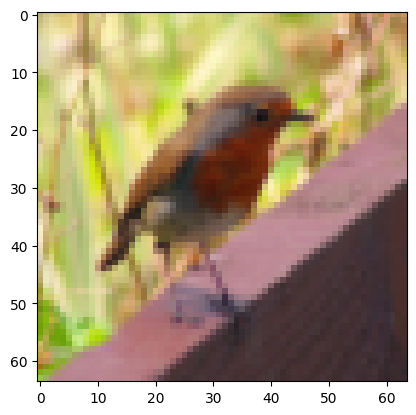

Label: 0


In [20]:
index = 10
plt.imshow(train_set_x_orig[index])
plt.show()
print("Label:", train_set_y[0, index])

In [21]:
#flatten img
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

print("Flatten train shape:", train_set_x_flatten.shape)
print("Flatten test shape:", test_set_x_flatten.shape)


Flatten train shape: (12288, 209)
Flatten test shape: (12288, 50)


In [22]:
# NORMALIZATION
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.

In [23]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [24]:
def initialize_with_zeros(dim):
    w = np.zeros((dim, 1))
    b = 0
    return w, b

In [25]:
def propagate(w, b, X, Y):
    m=X.shape[1]
    #forward
    Z=np.dot(w.T,X)+b
    A=sigmoid(Z)

    cost=-(1/m)*(np.sum(Y*np.log(A+ 1e-8)+(1-Y)*np.log(1-A+1e-8)))

    #backward
    dZ = A - Y
    dw = (1/m) * np.dot(X, dZ.T)
    db = (1/m) * np.sum(dZ)

    
    cost = np.squeeze(cost)

    grads = {
        "dw": dw,
        "db": db
    }

    return grads, cost

In [26]:
def optimizer(w, b, X, Y, num_iterations, learning_rate, print_cost=False):
    costs=[]
    for i in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)

        dw=grads["dw"]
        db=grads["db"]

        # UPDATE PARAMETERS
        w = w - learning_rate * dw
        b = b - learning_rate * db

        if i % 100 == 0:
            costs.append(cost)

        if print_cost and i % 100 == 0:
            print("Cost after iteration %i: %f" % (i, cost))

    params={
        "w" : w,
        "b" : b
    }
    grads = {
        "dw": dw,
        "db": db
    } 
    print(w.shape)
    print(b.shape)
    return params, grads, costs
   

In [27]:
 def predict(w, b, X):
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))#initially sare pred 0 2D
    w = w.reshape(X.shape[0], 1)#w ko x ka shape mai kiya
    Z = np.dot(w.T, X) + b #zdim =(1, m)
    A = sigmoid(Z)
    for i in range(A.shape[1]):
        if A[0, i] > 0.5:
            Y_prediction[0, i] = 1
        else:
            Y_prediction[0, i] = 0

    return Y_prediction    

In [28]:
def model( X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.005, print_cost=False):
    w, b = initialize_with_zeros(X_train.shape[0]) 
    params, grads, costs= optimizer(w,b,X_train,Y_train,num_iterations, learning_rate, print_cost) 
    w=params["w"] 
    b=params["b"]
    Y_prediction_test= predict(w,b,X_test)
    Y_prediction_train= predict(w,b,X_train) 
    #accuracy 
    train_accuracy = np.mean(Y_prediction_train == Y_train) * 100
    test_accuracy = np.mean(Y_prediction_test == Y_test) * 100 
    print("Train accuracy: {} %".format(train_accuracy))
    print("Test accuracy: {} %".format(test_accuracy)) 
    d={ "costs": costs,
        "Y_prediction_test": Y_prediction_test, 
        "Y_prediction_train": Y_prediction_train, 
        "w": w,
        "b": b,
        "learning_rate": learning_rate,
        "num_iterations": num_iterations }
    return d

In [29]:
d=model(train_set_x,train_set_y,test_set_x,test_set_y,num_iterations=2000, learning_rate=0.005, print_cost=True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.584508
Cost after iteration 200: 0.466949
Cost after iteration 300: 0.376007
Cost after iteration 400: 0.331463
Cost after iteration 500: 0.303273
Cost after iteration 600: 0.279880
Cost after iteration 700: 0.260042
Cost after iteration 800: 0.242941
Cost after iteration 900: 0.228004
Cost after iteration 1000: 0.214820
Cost after iteration 1100: 0.203078
Cost after iteration 1200: 0.192544
Cost after iteration 1300: 0.183033
Cost after iteration 1400: 0.174399
Cost after iteration 1500: 0.166521
Cost after iteration 1600: 0.159305
Cost after iteration 1700: 0.152667
Cost after iteration 1800: 0.146542
Cost after iteration 1900: 0.140872
(12288, 1)
()
Train accuracy: 99.04306220095694 %
Test accuracy: 70.0 %


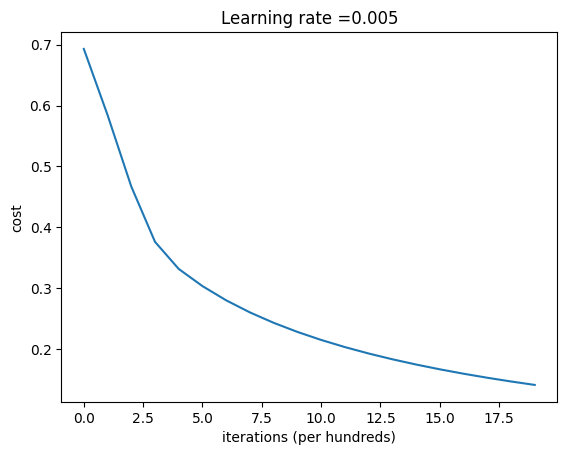

In [30]:
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(d["learning_rate"]))
plt.show()